Overview of geospatial Python libraries used and optional install command

Rasterio - Reads and writes geospatial raster files (satellite images, DEMs, GeoTIFFs)

GeoPandas - Pandas extension for working with geospatial vector data (shapefiles, polygons, points)

Shapely - Creates and manipulates geometric shapes (points, lines, polygons)

Pyproj - Converts between different coordinate systems and map projections

Matplotlib - Creates plots, charts, and visualizations

NumPy - Fast array operations and mathematical computations

SciPy - Advanced scientific computing (statistics, signal processing, filters)

Run this if env does't have this:

%pip install rasterio geopandas shapely pyproj matplotlib numpy scipy

In [20]:
# Mount Google Drive for data access
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [21]:
# Download Mars global DEM to Drive if missing
import os
import urllib.request

# Create a directory in Google Drive to store data
drive_data_path = "/content/gdrive/MyDrive/colab_data"
os.makedirs(drive_data_path, exist_ok=True)

# URL of data from nasa's site
dem_url = (
    "https://planetarymaps.usgs.gov/mosaic/Mars/HRSC_MOLA_Blend/Mars_HRSC_MOLA_BlendDEM_Global_200mp_v2.tif"
),

# Path in Google Drive
dem_path = os.path.join(drive_data_path, "mars_global_dem_200m.tif")

# Download if not present in directory
if not os.path.exists(dem_path):
    print("Downloading Mars global DEM (this may take a few minutes)...")

    opener = urllib.request.build_opener()
    opener.addheaders = [('User-Agent', 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3')]
    urllib.request.install_opener(opener)

    # Use the custom opener to retrieve the URL
    urllib.request.urlretrieve(dem_url, dem_path)
    print("Download complete.")
else:
    print("DEM already exists.")


DEM already exists.


In [22]:
# Clip global DEM to Gale Crater bounding box and save to Drive
import rasterio
from rasterio.windows import from_bounds

# Curiosity landing site in Gale Crater bounding box (degrees)
lat_min, lat_max = -5.12044, -4.45392
lon_min, lon_max = 136.46052 ,137.8255

# Clipped region output path in Google Drive
output_path = os.path.join(drive_data_path, "Gale_Creater_dem.tif")

try:
    with rasterio.open(dem_path) as src:
        print("CRS:", src.crs)

        # Create window from geographic bounds
        window = from_bounds(
            lon_min, lat_min,
            lon_max, lat_max,
            transform=src.transform
        )

        Gale_data = src.read(1, window=window)
        Gale_transform = src.window_transform(window)

        meta = src.meta.copy()
        meta.update({
            "height": Gale_data.shape[0],
            "width": Gale_data.shape[1],
            "transform": Gale_transform
        })

        with rasterio.open(output_path, "w", **meta) as dst:
            dst.write(Gale_data, 1)

    print("Gale DEM saved at:", output_path)
except rasterio.RasterioIOError as e:
    print(f"Error reading DEM file: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


CRS: ESRI:104971
Gale DEM saved at: /content/gdrive/MyDrive/colab_data/Gale_Creater_dem.tif


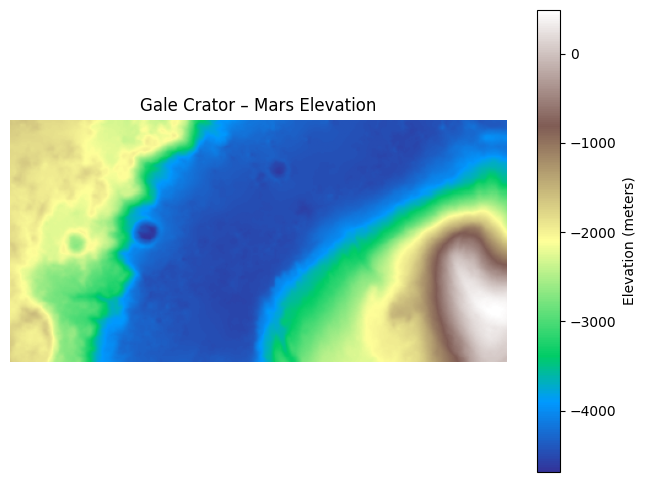

In [23]:
# Visualize clipped DEM elevation
import matplotlib.pyplot as plt

with rasterio.open(output_path) as dem:
    elevation = dem.read(1)

plt.figure(figsize=(8,6))
plt.imshow(elevation, cmap="terrain")
plt.colorbar(label="Elevation (meters)")
plt.title("Gale Crator – Mars Elevation")
plt.axis("off")
plt.show()

In [24]:
# Compute slope in degrees from DEM
import numpy as np
import rasterio
from scipy.ndimage import sobel

with rasterio.open(output_path) as src:
    dem = src.read(1).astype(float)
    transform = src.transform

    # Original pixel size in degrees (from the coordinate system)
    pixel_size_degrees = transform.a

    # Mars equatorial radius in meters (approximate value)
    mars_equatorial_radius_meters = 3396200.0 # 3396.2 km

    # Convert pixel size from degrees to meters
    # The length of one degree of longitude/latitude in meters at the equator
    meters_per_degree = (2 * np.pi * mars_equatorial_radius_meters) / 360.0

    # Calculate the pixel size in meters
    pixel_size = pixel_size_degrees * meters_per_degree

# Compute gradients
# The Sobel filter output from scipy.ndimage.sobel is scaled by 1/8 internally
# for integer inputs to preserve magnitude. When using float inputs,
# it is common practice to still divide by 8 * pixel_size to normalize the gradient
# into change in elevation per meter.
dzdx = sobel(dem, axis=1) / (8 * pixel_size)
dzdy = sobel(dem, axis=0) / (8 * pixel_size)

# Slope in degrees
slope = np.degrees(np.arctan(np.sqrt(dzdx**2 + dzdy**2)))

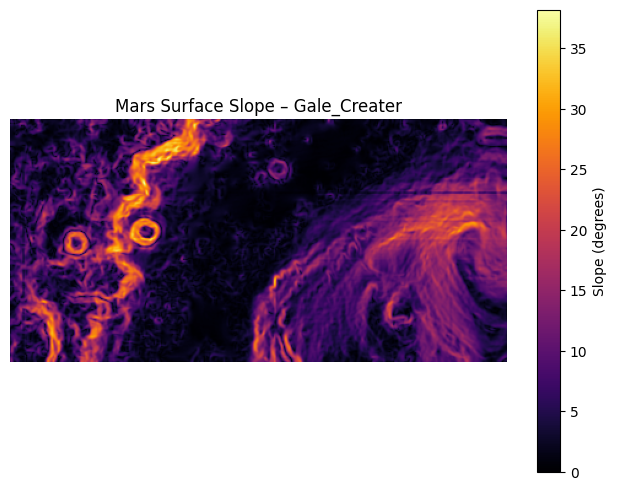

In [25]:
# Plot slope map
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.imshow(slope, cmap="inferno")
plt.colorbar(label="Slope (degrees)")
plt.title("Mars Surface Slope – Gale_Creater")
plt.axis("off")
plt.show()


In [26]:
# Compute surface roughness using local std dev
from scipy.ndimage import generic_filter

def roughness_func(window):
    return np.std(window)

roughness = generic_filter(dem, roughness_func, size=5)

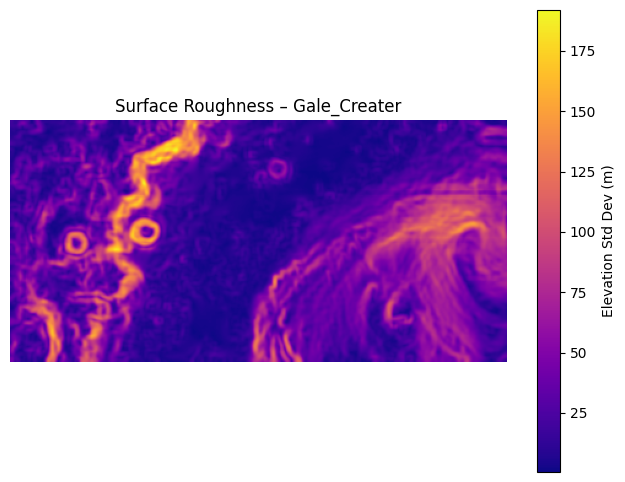

In [27]:
# Plot roughness map
plt.figure(figsize=(8,6))
plt.imshow(roughness, cmap="plasma")
plt.colorbar(label="Elevation Std Dev (m)")
plt.title("Surface Roughness – Gale_Creater")
plt.axis("off")
plt.show()

In [28]:
# Create binary safe landing mask using slope/roughness thresholds
SLOPE_THRESHOLD = 5      # degrees
ROUGHNESS_THRESHOLD = 20  # meters

safe_mask = (slope <= SLOPE_THRESHOLD) & (roughness <= ROUGHNESS_THRESHOLD)

labels = np.zeros_like(dem, dtype=np.uint8)
labels[safe_mask] = 1

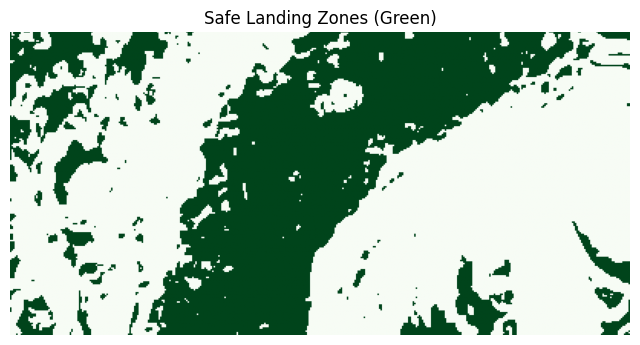

In [29]:
# Visualize binary safe landing zones
plt.figure(figsize=(8,6))
plt.imshow(labels, cmap="Greens")
plt.title("Safe Landing Zones (Green)")
plt.axis("off")
plt.show()

In [30]:
# Build multi-class label map: unsafe(0), moderate(1), safe(2)
labels_multi = np.zeros_like(dem, dtype=np.uint8)

# Define masks with explicit priority to avoid overwriting SAFE as MODERATE
safe_mask = (slope <= 7) & (roughness <= 10)
moderate_mask = (
    (((slope > 5) & (slope <= 10)) | ((roughness > 1.5) & (roughness <= 3)))
    & (~safe_mask)
    )

labels_multi[moderate_mask] = 1
labels_multi[safe_mask] = 2

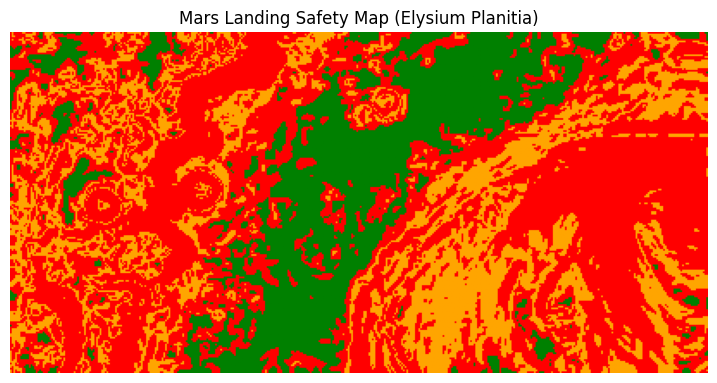

In [31]:
# Visualize multi-class safety map
import matplotlib.colors as colors

cmap = colors.ListedColormap(["red", "orange", "green"])
bounds = [0, 1, 2, 3]
norm = colors.BoundaryNorm(bounds, cmap.N)

plt.figure(figsize=(9,5))
plt.imshow(labels_multi, cmap=cmap, norm=norm)
plt.title("Mars Landing Safety Map (Elysium Planitia)")
plt.axis("off")
plt.show()

In [32]:
# Stack elevation, slope, and roughness into a 3-channel array
import numpy as np

# Stack input channels ,adds a new first dimension and combines them into one array with shape (3, H, W)
input_stack = np.stack([dem, slope, roughness], axis=0)

print("Input shape:", input_stack.shape)
print("Label shape:", labels_multi.shape)

Input shape: (3, 198, 405)
Label shape: (198, 405)


In [33]:
# Normalize each channel to 0-1
def normalize(x):
    return (x - np.min(x)) / (np.max(x) - np.min(x))

input_stack_norm = np.stack([
    normalize(dem),
    normalize(slope),
    normalize(roughness)
], axis=0)


In [34]:
# Extract sliding-window patches for PyTorch training
PATCH_SIZE = 128
stride = 16

patches = []
masks = []

C, H, W = input_stack_norm.shape

for i in range(0, H - PATCH_SIZE, stride):
    for j in range(0, W - PATCH_SIZE, stride):
        patch = input_stack_norm[:, i:i+PATCH_SIZE, j:j+PATCH_SIZE]
        mask = labels_multi[i:i+PATCH_SIZE, j:j+PATCH_SIZE]

        patches.append(patch)
        masks.append(mask)

patches = np.array(patches)
masks = np.array(masks)

print("Total patches:", len(patches))
print("Patch shape:", patches.shape)

Total patches: 90
Patch shape: (90, 3, 128, 128)


In [35]:
# Split patches into train and validation sets
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    patches, masks, test_size=0.3, random_state=27
)

print("Train samples:", len(X_train))
print("Validation samples:", len(X_val))

Train samples: 63
Validation samples: 27


In [36]:
# Wrap patches in a PyTorch Dataset
import torch
from torch.utils.data import Dataset

class MarsDataset(Dataset):
    def __init__(self, images, masks):
        self.images = torch.tensor(images, dtype=torch.float32)
        self.masks = torch.tensor(masks, dtype=torch.long)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.masks[idx]

train_dataset = MarsDataset(X_train, y_train)
val_dataset = MarsDataset(X_val, y_val)

In [37]:
# Create PyTorch DataLoaders
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8)

In [38]:
# Define a lightweight PyTorch U-Net
import torch.nn as nn
import torch.nn.functional as F

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=3):
        super(UNet, self).__init__()

        self.enc1 = nn.Conv2d(in_channels, 32, 3, padding=1)
        self.enc2 = nn.Conv2d(32, 64, 3, padding=1)

        self.pool = nn.MaxPool2d(2)

        self.dec1 = nn.Conv2d(64, 32, 3, padding=1)
        self.final = nn.Conv2d(32, out_channels, 1)

    def forward(self, x):
        x1 = F.relu(self.enc1(x))
        x2 = self.pool(x1)
        x3 = F.relu(self.enc2(x2))

        x4 = F.interpolate(x3, scale_factor=2, mode='bilinear', align_corners=False)
        x5 = F.relu(self.dec1(x4))

        return self.final(x5)

model = UNet()

In [39]:
# Move model to device and set optimizer/loss
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

In [40]:
# Train PyTorch model for a few epochs
for epoch in range(5):
    model.train()
    total_loss = 0

    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader)}")

Epoch 1, Loss: 1.0401864275336266
Epoch 2, Loss: 0.8896194025874138
Epoch 3, Loss: 0.8015658184885979
Epoch 4, Loss: 0.7347386479377747
Epoch 5, Loss: 0.655387856066227


In [41]:
# Recompute normalized patches for TensorFlow pipeline
import numpy as np
import rasterio
from sklearn.model_selection import train_test_split
import os

# Load processed rasters (using already computed variables)
elev = dem
slope = slope
rough = roughness
label = labels_multi

def normalize_channel(channel):
    cmin = np.min(channel)
    cmax = np.max(channel)
    return (channel - cmin) / (cmax - cmin + 1e-8)

# Stack inputs with per-channel normalization
X = np.stack([
    normalize_channel(elev),
    normalize_channel(slope),
    normalize_channel(rough)
], axis=0)

patch_size = 128
stride = 8

def create_patches(data, labels, patch_size):
    patches = []
    patch_labels = []
    h, w = labels.shape

    for i in range(0, h - patch_size, stride):
        for j in range(0, w - patch_size, stride):
            patch = data[:, i:i+patch_size, j:j+patch_size]
            lab = labels[i:i+patch_size, j:j+patch_size]
            patches.append(patch)
            patch_labels.append(lab)

    return np.array(patches), np.array(patch_labels)

X_patches, y_patches = create_patches(X, label, patch_size)

# Train/Test Split
X_train, X_val, y_train, y_val = train_test_split(
    X_patches, y_patches, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape)

Training samples: (252, 3, 128, 128)


In [42]:
# Define TensorFlow U-Net and class-weighted loss
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models

def unet_model(input_size=(128, 128, 3), n_classes=3):
    inputs = layers.Input(input_size)

    # Encoder
    c1 = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(32, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(64, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(64, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D()(c2)

    # Bottleneck
    b = layers.Conv2D(128, 3, activation='relu', padding='same')(p2)

    # Decoder
    u1 = layers.UpSampling2D()(b)
    u1 = layers.concatenate([u1, c2])
    c3 = layers.Conv2D(64, 3, activation='relu', padding='same')(u1)

    u2 = layers.UpSampling2D()(c3)
    u2 = layers.concatenate([u2, c1])
    c4 = layers.Conv2D(32, 3, activation='relu', padding='same')(u2)

    outputs = layers.Conv2D(n_classes, 1, activation='softmax')(c4)

    return models.Model(inputs, outputs)

# Compute class weights from training masks to reduce class imbalance
num_classes = 3
class_counts = np.bincount(y_train.reshape(-1), minlength=num_classes)
total_pixels = class_counts.sum()
if np.any(class_counts == 0):
    print("Warning: missing class in training data:", class_counts)
class_weights = total_pixels / (num_classes * np.maximum(class_counts, 1))
class_weights = class_weights.astype("float32")

def weighted_sce(y_true, y_pred):
    y_true = tf.cast(y_true, tf.int32)
    weights = tf.gather(class_weights, y_true)
    loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
    return loss * weights

model = unet_model()
model.compile(optimizer='adam',
              loss=weighted_sce,
              metrics=['accuracy'])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 64, 64,    │          0 │ conv2d_4[0][0]    │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 192)              │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    110,656 │ concatenate[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 128, 128,  │          0 │ conv2d_5[0][0]    │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 128, 128,  │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 96)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 128, 128,  │     27,680 │ concatenate_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 128, 128,  │         99 │ conv2d_6[0][0]    │
│                     │ 3)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 277,859 (1.06 MB)

 Trainable params: 277,859 (1.06 MB)

 Non-trainable params: 0 (0.00 B)

In [43]:
# Train TensorFlow model
history = model.fit(
    X_train.transpose(0,2,3,1),   # reshape to (samples, h, w, channels)
    y_train,
    validation_data=(X_val.transpose(0,2,3,1), y_val),
    epochs=20,
    batch_size=8
)

print("MODEL TRAINED")

Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 24s 405ms/step - accuracy: 0.5690 - loss: 0.9088 - val_accuracy: 0.6838 - val_loss: 0.6055
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.7058 - loss: 0.5459 - val_accuracy: 0.7962 - val_loss: 0.3721
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8119 - loss: 0.3624 - val_accuracy: 0.8511 - val_loss: 0.3022
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8461 - loss: 0.2985 - val_accuracy: 0.8538 - val_loss: 0.3108
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8576 - loss: 0.2841 - val_accuracy: 0.8788 - val_loss: 0.2306
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8873 - loss: 0.2224 - val_accuracy: 0.9084 - val_loss: 0.1953
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8986 - loss: 0.2020 - val_accuracy: 0.9014 - val_loss: 0.1804
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8916 - loss: 0.2162 - val_accuracy: 0.9025 -

In [44]:
# Predict class probabilities on validation set
pred = model.predict(X_val.transpose(0,2,3,1))
pred_classes = np.argmax(pred, axis=-1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 3s/step


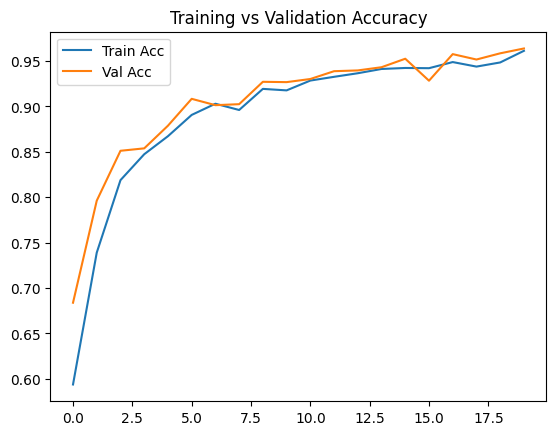

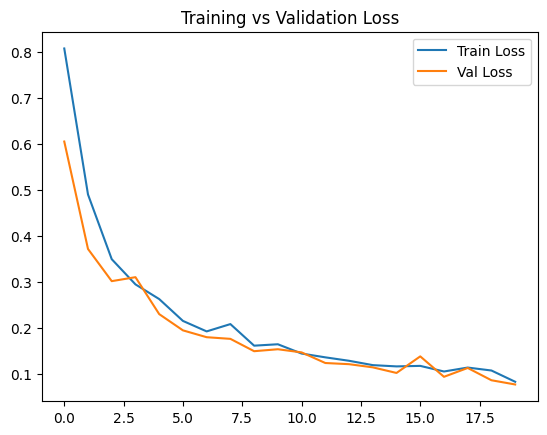

In [45]:
# Plot training vs validation accuracy and loss
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

In [46]:
# Compute pixel-wise accuracy on validation set
import numpy as np

val_pred = model.predict(X_val.transpose(0,2,3,1))
val_pred_classes = np.argmax(val_pred, axis=-1)

pixel_accuracy = np.mean(val_pred_classes == y_val)
print("Pixel Accuracy:", pixel_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Pixel Accuracy: 0.9638197157118056


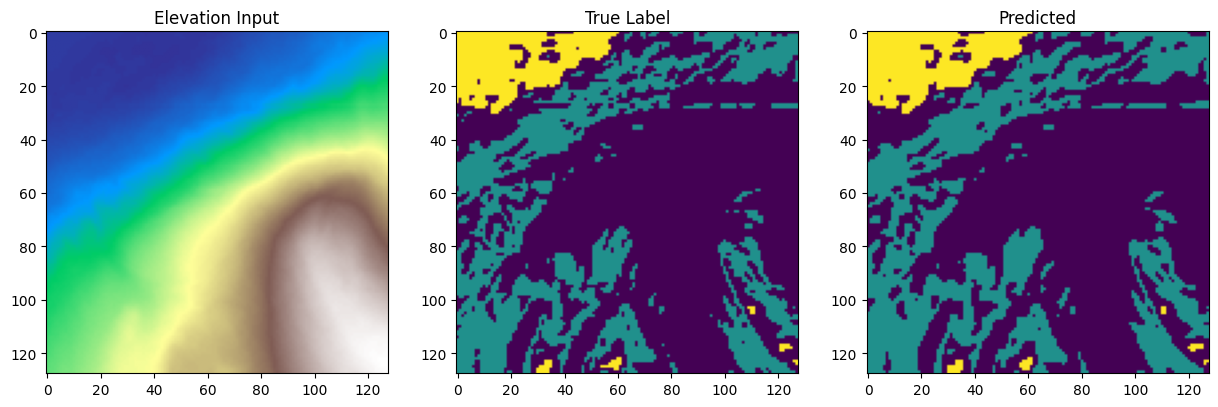

In [48]:
# Visualize a random validation patch, its label, and prediction
import random
idx = random.randint(0, len(X_val)-1)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Elevation Input")
plt.imshow(X_val[idx][0], cmap='terrain')

plt.subplot(1,3,2)
plt.title("True Label")
plt.imshow(y_val[idx], cmap='viridis')

plt.subplot(1,3,3)
plt.title("Predicted")
plt.imshow(val_pred_classes[idx], cmap='viridis')

plt.show()

Class distribution summary for training masks

In [49]:
# Print class counts and percentages in training set
import numpy as np

unique, counts = np.unique(y_train, return_counts=True)

total = counts.sum()
for u, c in zip(unique, counts):
    print(f"Class {u}: {c} pixels ({c/total:.2%})")
print("Total pixels:", total)

Class 0: 2066722 pixels (50.06%)
Class 1: 950102 pixels (23.01%)
Class 2: 1111944 pixels (26.93%)
Total pixels: 4128768


In [50]:
model_version = 1.0
model.save(f'{drive_data_path}/{model_version}/model.h5')

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted map shape: (198, 405)


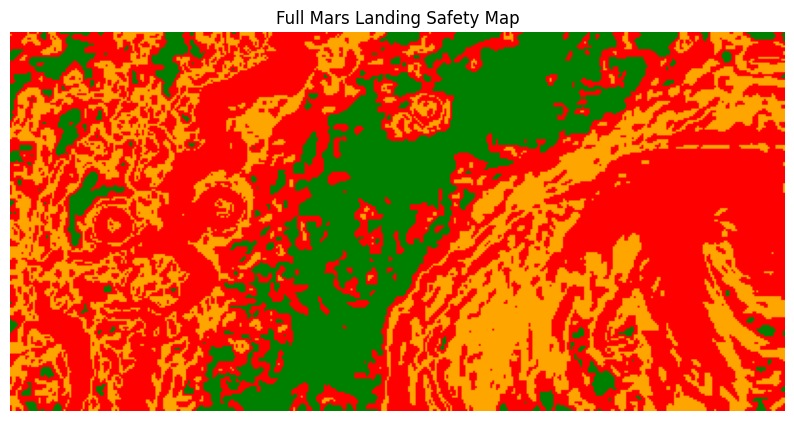

In [52]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# Convert input to TensorFlow format (H,W,C)
input_tensor = np.transpose(X, (1, 2, 0))

# Pad to make H and W divisible by 4 (2 pooling layers)
h, w, c = input_tensor.shape
pad_h = (4 - (h % 4)) % 4
pad_w = (4 - (w % 4)) % 4
input_padded = np.pad(
    input_tensor,
    ((0, pad_h), (0, pad_w), (0, 0)),
    mode="edge"
 )

# Add batch dimension
input_padded = np.expand_dims(input_padded, axis=0)

# Predict full map
prediction = model.predict(input_padded)
predicted_map = np.argmax(prediction[0], axis=-1)

# Remove padding to restore original size
predicted_map = predicted_map[:h, :w]

print("Predicted map shape:", predicted_map.shape)

# Visualize full landing safety map
cmap = colors.ListedColormap(["red", "orange", "green"])
bounds = [0, 1, 2, 3]
norm = colors.BoundaryNorm(bounds, cmap.N)

plt.figure(figsize=(10, 6))
plt.imshow(predicted_map, cmap=cmap, norm=norm)
plt.title("Full Mars Landing Safety Map")
plt.axis("off")
plt.show()

In [53]:
safe_pixels = np.where(predicted_map==2)

print("Safe landing pixels:", len(safe_pixels[0]))

Safe landing pixels: 17292


In [54]:
best_index = np.random.randint(0,len(safe_pixels[0]))

y = safe_pixels[0][best_index]
x = safe_pixels[1][best_index]

print("Recommended Landing Pixel:",x,y)

Recommended Landing Pixel: 270 22


Largest safe pathc

In [55]:
import numpy as np

safe_map = (predicted_map == 2).astype(np.uint8)

print("Safe pixels:", np.sum(safe_map))

Safe pixels: 17292


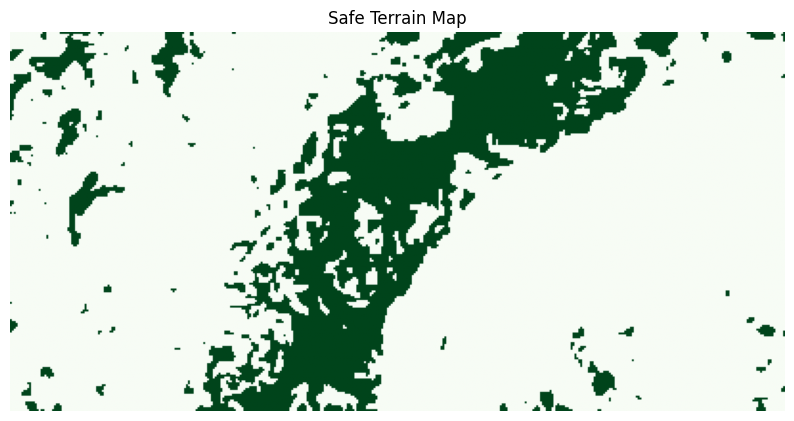

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.imshow(safe_map, cmap="Greens")
plt.title("Safe Terrain Map")
plt.axis("off")
plt.show()

In [57]:
from scipy.ndimage import label

labeled_map, num_regions = label(safe_map)

print("Number of safe regions:", num_regions)

Number of safe regions: 135


In [58]:
region_sizes = []

for i in range(1, num_regions + 1):
    size = np.sum(labeled_map == i)
    region_sizes.append((i, size))

# sort largest first
region_sizes.sort(key=lambda x: x[1], reverse=True)

print("Top 10 largest landing zones:")
print(region_sizes[:10])

Top 10 largest landing zones:
[(8, np.int64(13974)), (2, np.int64(376)), (62, np.int64(312)), (4, np.int64(303)), (9, np.int64(199)), (43, np.int64(185)), (113, np.int64(137)), (31, np.int64(136)), (49, np.int64(131)), (7, np.int64(106))]


In [59]:
largest_region_id = region_sizes[0][0]

largest_zone = (labeled_map == largest_region_id)

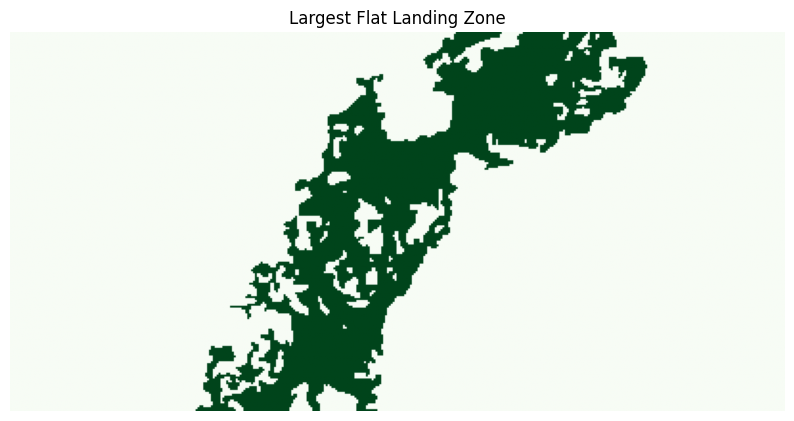

In [60]:
plt.figure(figsize=(10,6))
plt.imshow(largest_zone, cmap="Greens")
plt.title("Largest Flat Landing Zone")
plt.axis("off")
plt.show()

In [61]:
coords = np.column_stack(np.where(largest_zone))

center_y = int(np.mean(coords[:,0]))
center_x = int(np.mean(coords[:,1]))

print("Recommended Landing Coordinate:")
print("X:", center_x)
print("Y:", center_y)

Recommended Landing Coordinate:
X: 207
Y: 89


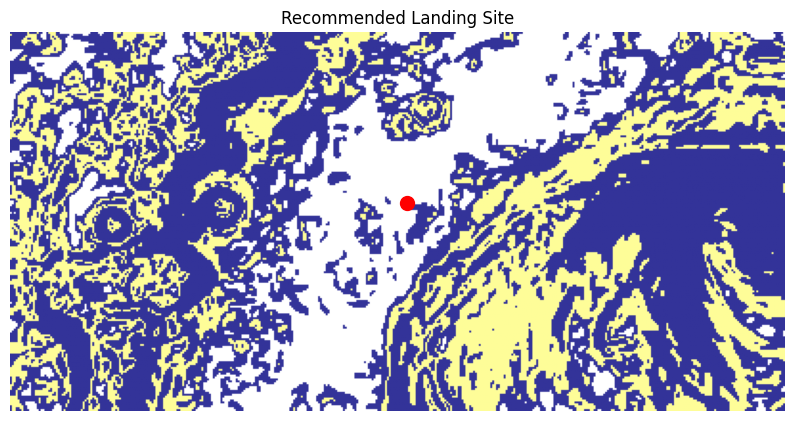

In [62]:
plt.figure(figsize=(10,6))

plt.imshow(predicted_map, cmap="terrain")

plt.scatter(center_x, center_y, c="red", s=100)

plt.title("Recommended Landing Site")
plt.axis("off")

plt.show()

In [ ]:
# Install Flask and pyngrok in Colab
!pip install flask pyngrok -q